<a href="https://colab.research.google.com/github/hyunhyun42/Data-Analysis-with-Open-Source/blob/main/%EC%98%A4%ED%94%88%EC%86%8C%EC%8A%A4_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EC%84%9D_4%EA%B0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# 오픈소스 기반 데이터 분석 4강 - 데이터 수집


## 4-1 CSV 파일 읽기

In [ ]:
import pandas as pd

## data.csv 파일 읽기
df=pd.read_csv('data.csv', encoding='utf-8', sep=',', header=0,
               index_col=None, skiprows=None, nrows=None)

print(df)

           날짜    체중  골격근량  체지방량
0  2025.02.06  64.7  30.0  11.1
1  2025.02.04  64.0  29.3  11.6


## 4-2 JSON 파일 읽기



In [ ]:
import json
import pandas as pd

## data.json 파일 출력
with open('data.json', mode='r', encoding='utf-8') as f:
    data = json.load(f)
print(data)

## data.json 파일 DataFrame 읽기
df = pd.read_json('data.json', orient='records', encoding='utf-8', lines=False)
print(df)

{'매출데이터': [{'월': '2025-01', '매출액': 1000000, '비용': 700000, '이익': 300000}, {'월': '2025-02', '매출액': 1200000, '비용': 800000, '이익': 400000}, {'월': '2025-03', '매출액': 1500000, '비용': 900000, '이익': 600000}]}
                                               매출데이터
0  {'월': '2025-01', '매출액': 1000000, '비용': 700000,...
1  {'월': '2025-02', '매출액': 1200000, '비용': 800000,...
2  {'월': '2025-03', '매출액': 1500000, '비용': 900000,...


## 4-3 텍스트 파일 읽기 및 데이터 추출

In [ ]:
import re

## 파일(callcenter20250301.log) 오픈 및 읽기
with open('callcenter20250301.log', 'r', encoding='utf-8') as f:
    content = f.read()
## 주민등록번호 패턴 생성
pattern=re.compile(r'(\d{6})-(\d{7})')

## 주민등록번호 마스킹
masked_content = pattern.sub(r'\1-*******', content)

## 마스킹된 파일(callcenter20250301_masked.log) 오픈 및 쓰기
with open('callcenter20250301_masked.log', mode='w') as f:
    f.write(masked_content)

print("주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.")

주민등록번호 마스킹 완료. 'callcenter20250301_masked.log.txt' 파일로 저장되었습니다.


## 4-4 Open-Meteo의 무료 날씨 API를 통한 특정 지역 온도 조회

In [ ]:
import requests
import json

url = "https://api.open-meteo.com/v1/forecast?=&=&current=temperature_2m"
params = {
    "latitude": "37.58638333",
    "longitude": "127.0203333",
    "current": "temperature_2m"
}

try:
    ## URL 및 파라미터 전송
    response = requests.get(url, params=params)
    response.raise_for_status()

    ## JSON 데이터 읽기
    data = response. json()

    print("API 응답:", data)
    print("서울시 종로구의 현재 온도는 : {0}{1} 입니다.".format(data['current']['temperature_2m'], data['current_units']['temperature_2m']))

except requests.exceptions.RequestException as e:
    print(f"API 호출 실패: {e}")
except json.JSONDecodeError as e:
    print(f"JSON 파싱 실패: {e}")

API 응답: {'latitude': 37.6, 'longitude': 127.0, 'generationtime_ms': 0.05316734313964844, 'utc_offset_seconds': 0, 'timezone': 'GMT', 'timezone_abbreviation': 'GMT', 'elevation': 29.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C'}, 'current': {'time': '2026-09-29T05:30', 'interval': 900, 'temperature_2m': 24.6}}
서울시 종로구의 현재 온도는 : 24.6°C 입니다.


## 4-5 Selenium과 lxml을 이용한 웹 스크래핑

In [ ]:
!curl -o google-chrome-stable_current_amd64.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!apt install ./google-chrome-stable_current_amd64.deb -y
!pip install selenium webdriver_manager

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  135M  100  135M    0     0   282M      0 --:--:-- --:--:-- --:--:--  282M
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'google-chrome-stable' instead of './google-chrome-stable_current_amd64.deb'
google-chrome-stable is already the newest version (154.0.8037.57-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.


In [ ]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service as ChromeService
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from lxml import html
import time

chrome_options = webdriver.ChromeOptions()
chrome_options.add_argument('--headless')               # 브라우저 창 없이 실행
chrome_options.add_argument('--no-sandbox')             # 보안모드 비활성화 (Colab 필수)
chrome_options.add_argument('--disable-dev-shm-usage')  # 메모리 부족 방지 (Colab 필수)
chrome_options.add_argument('--window-size=1920x1080')  # 창 크기 설정(가상)
chrome_options.add_argument('--disable-gpu')            # GPU 가속 비활성화 (일부 환경 안정성)
chrome_options.binary_location = "/usr/bin/google-chrome-stable"  # Colab용 크롬 경로 지정

## 드라이버 실행
driver = webdriver.Chrome(options=chrome_options)

## 사이트 접속
url = 'https://professor.knou.ac.kr/jaehwachung/index.do'
driver.get(url)

## 사이트 접속 대기
time.sleep(2)

## 페이지 제목 출력
page_source = driver.page_source
tree = html.fromstring(page_source)

title_text = tree.xpath('//title/text()')
print(title_text)

## 드라이버 종료
driver.quit()

['컴퓨터과학과 정재화 교수']



# 실습 시나리오

## 공공데이터 포털 가입 및 데이터 신청

- [https://www.data.go.kr](https://www.data.go.kr)
- 한국환경공단 에어코리아 대기오염정보 데이터 신청

In [ ]:
import requests

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552584/ArpltnlnforlnqireSvc/getCtprvnRltmMesureDnsty'
api_key = '인증키'

params = {
    'serviceKey': api_key,
    'returnType': 'json',
    'numOfRows': '100',
    'pageNo': '1',
    'sidoName': '서울',
    'ver': '1.0'
}

## 데이터 수집
response = requests.get(url, params=params)

## 호출 성공/실패 출력
print(response.json())


{'OpenAPI_ServiceResponse': {'cmmMsgHeader': {'errMsg': 'NO_OPENAPI_SERVICE_ERROR', 'returnAuthMsg': '해당 오픈API 서비스가 없거나 폐기됨', 'returnReasonCode': '12'}}}


과제 1-2

In [6]:
import requests

api_key = '30d08d1784477a95993e326bcf11a6f30f7d349158e514887e8b8ac49408375a'

all_data = []

for year in range(2015, 2025):
    for code in ['01', '02', '03', '06']:
        url = f"https://apis.data.go.kr/B552845/perDay/price?serviceKey={api_key}&pageNo=1&numOfRows=200&returnType=JSON&cond[exmn_ymd::GTE]={year}0101&cond[exmn_ymd::LTE]={year}1231&cond[se_cd::EQ]=02&cond[ctgry_cd::EQ]=200&cond[item_cd::EQ]=211&cond[grd_cd::EQ]=04&cond[sgg_cd::EQ]=1101&cond[mrkt_cd::EQ]=0110211&cond[vrty_cd::EQ]={code}"

        response = requests.get(url)
        res_json = response.json()

        items = res_json['response']['body']['items']['item']
        all_data.extend(items)

print(f"{len(all_data)}건")

2644건


In [7]:
import pandas as pd

df = pd.DataFrame(all_data)

print(df.index)
print(df.columns)
print(df.values.tolist()[:1])
print(df.values[:1, :5].flatten())

RangeIndex(start=0, stop=2644, step=1)
Index(['ctgry_cd', 'ctgry_nm', 'exmn_dd_cnvs_prc', 'exmn_dd_prc', 'exmn_ymd',
       'grd_cd', 'grd_nm', 'item_cd', 'item_nm', 'mrkt_cd', 'mrkt_nm',
       'orgnl_reg_dt', 'se_cd', 'se_nm', 'sgg_cd', 'sgg_nm', 'unit', 'unit_sz',
       'vrty_cd', 'vrty_nm'],
      dtype='object')
[['200', '채소류', '9000', '9000', '20150512', '04', '상품', '211', '배추', '0110211', '가락도매', '2015-05-12T13:53:35Z', '02', '중도매', '1101', '서울', 'kg(그물망 3포기)', '10', '01', '봄']]
['200' '채소류' '9000' '9000' '20150512']


In [8]:
df['date'] = pd.to_datetime(df['exmn_ymd'])

df['year'] = df['date'].dt.year

def get_season(month):
    if month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    elif month in [9, 10, 11]:
        return '가을'
    else:
        return '겨울'

df['season'] = df['date'].dt.month.apply(get_season)
df[['exmn_ymd', 'year', 'season']].head()

,exmn_ymd,year,season
0,20150512,2015,봄
1,20150513,2015,봄
2,20150514,2015,봄
3,20150515,2015,봄
4,20150518,2015,봄


In [9]:
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
Font directories:
	/root/.local/share/fonts
	/usr/local/share/fonts
	/usr/share/fonts
	/root/.fonts
	/usr/share/fonts/truetype
	/usr/share/fonts/truetype/humor-sans
	/usr/share/fonts/truetype/liberation
	/usr/share/fonts/truetype/nanum
/root/.local/share/fonts: skipping, no such directory
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 12 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/root/.fonts: skipping, no such directory
/u

In [1]:
import matplotlib.pyplot as plt
plt.rc('font', family='NanumBarunGothic')

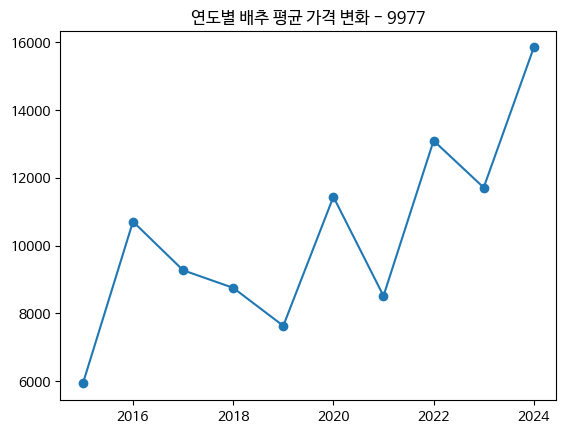

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'])

yearly_avg = df.groupby('year')['exmn_dd_prc'].mean()

x = yearly_avg.index
y = yearly_avg.values

plt.plot(x, y, marker='o')

plt.title('연도별 배추 평균 가격 변화 - 9977')

plt.show()

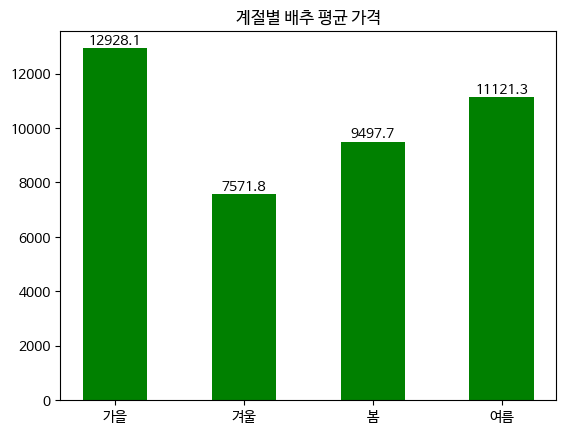

In [10]:
import matplotlib.pyplot as plt

seasonal_avg = df.groupby('season')['exmn_dd_prc'].mean()

categories = seasonal_avg.index
values = seasonal_avg.values

bars = plt.bar(categories, values, width=0.5, color='green')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom')

plt.title('계절별 배추 평균 가격')
plt.show()